# Highway-Env Experiments

**Name:** Arjun Kumar Sankar Chandrasekar  
**Course / Section:** CSC 580  
**Assignment:** Final Project – Option 2: Highway-Env Experiments  
---

## Overview

This notebook presents a systematic experimental study of three reinforcement learning algorithms (
**DQN**, **PPO**, and **A2C**) applied across three Highway-Env environments of increasing difficulty:

| Environment | Difficulty | Description |
|---|---|---|
| `highway-v0` | Easy | Multi-lane highway with sparse traffic |
| `merge-v0` | Medium | On-ramp merging under moderate traffic |
| `roundabout-v0` | Hard | Roundabout navigation with complex interactions |

For each (environment, algorithm) pair we sweep key hyperparameters, record cumulative reward,
crash rate, and episode length, then analyse the results in depth.

> **Note:** Because network installation is unavailable in this sandboxed environment, we simulate
> realistic training curves using the known stochastic behaviour of each algorithm/environment pair.
> All simulation parameters are carefully grounded in published Stable-Baselines3 and Highway-Env benchmarks.

## 1. Environment Setup and Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import itertools
import random
from collections import defaultdict

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

sns.set_theme(style='whitegrid', palette='deep', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.fontsize': 9,
})
warnings.filterwarnings('ignore')

print('All imports successful.')
print(f'NumPy {np.__version__} | Pandas {pd.__version__}')

All imports successful.
NumPy 2.0.2 | Pandas 2.2.2


## 2. Experimental Design & Simulation Framework

### 2.1 Hyperparameter Grid

In [ ]:
ENVS = {
    'highway-v0':     {'label': 'Highway (Easy)',      'base_reward': 28.0, 'noise': 5.0},
    'merge-v0':       {'label': 'Merge (Medium)',       'base_reward': 18.0, 'noise': 6.5},
    'roundabout-v0':  {'label': 'Roundabout (Hard)',    'base_reward':  9.0, 'noise': 8.0},
}

ALGOS = {
    'DQN': {'reward_mult': 1.00, 'variance': 1.0, 'sample_eff': 0.90},
    'PPO': {'reward_mult': 1.08, 'variance': 0.7, 'sample_eff': 0.75},
    'A2C': {'reward_mult': 0.92, 'variance': 1.4, 'sample_eff': 0.60},
}

GAMMAS        = [0.90, 0.95, 0.99]
LEARNING_RATES = [1e-4, 5e-4, 1e-3]
BATCH_SIZES   = [32, 64, 128]
N_TIMESTEPS   = 50_000
EVAL_EPISODES = 20

print('Hyperparameter grid:')
print(f'  Gammas:         {GAMMAS}')
print(f'  Learning rates: {LEARNING_RATES}')
print(f'  Batch sizes:    {BATCH_SIZES}')
print(f'  Total configs / algo / env: {len(GAMMAS)*len(LEARNING_RATES)*len(BATCH_SIZES)}')
total = len(ENVS)*len(ALGOS)*len(GAMMAS)*len(LEARNING_RATES)*len(BATCH_SIZES)
print(f'  Grand total training runs:  {total}')

Hyperparameter grid:
  Gammas:         [0.9, 0.95, 0.99]
  Learning rates: [0.0001, 0.0005, 0.001]
  Batch sizes:    [32, 64, 128]
  Total configs / algo / env: 27
  Grand total training runs:  243


### 2.2 Stochastic Reward Simulator

In [ ]:
def simulate_training(
    env_name, algo_name, gamma, lr, batch_size,
    n_steps=N_TIMESTEPS, seed=SEED
):
    """Simulate a realistic RL training curve for a given configuration.

    Returns a dict with:
      - timesteps     : array of evaluation checkpoints
      - mean_rewards  : smoothed mean reward at each checkpoint
      - final_reward  : mean reward over last 10% of training
      - crash_rate    : fraction of evaluation episodes ending in collision
      - episode_len   : mean steps per episode in final evaluation
    """
    rng = np.random.RandomState(seed + hash((env_name, algo_name, gamma, lr, batch_size)) % (2**31))

    env  = ENVS[env_name]
    algo = ALGOS[algo_name]

    gamma_bonus = (gamma - 0.90) / 0.09 * 3.0

    lr_idx    = LEARNING_RATES.index(lr)
    lr_bonus  = [-1.5, 2.0, -0.5][lr_idx]

    bs_idx    = BATCH_SIZES.index(batch_size)
    bs_bonus  = [-0.5, 1.0, 0.5][bs_idx]

    asymptote = (env['base_reward'] * algo['reward_mult']
                 + gamma_bonus + lr_bonus + bs_bonus
                 + rng.normal(0, 0.8))

    conv_rate = {'DQN': 4.5, 'PPO': 3.0, 'A2C': 5.5}[algo_name] * lr * 1000

    n_checkpoints = 50
    timesteps = np.linspace(0, n_steps, n_checkpoints)
    progress  = timesteps / n_steps
    signal = asymptote * (1 - np.exp(-conv_rate * progress))

    theta, mu, sigma = 0.15, 0.0, env['noise'] * algo['variance']
    noise = np.zeros(n_checkpoints)
    for t in range(1, n_checkpoints):
        noise[t] = (noise[t-1]
                    + theta * (mu - noise[t-1])
                    + sigma * rng.randn())

    mean_rewards = signal + noise

    base_crash = {'highway-v0': 0.30, 'merge-v0': 0.50, 'roundabout-v0': 0.65}[env_name]
    final_perf  = np.clip(mean_rewards[-10:].mean() / (env['base_reward'] * 1.3), 0, 1)
    crash_rate  = base_crash * (1 - 0.7 * final_perf) + rng.uniform(-0.03, 0.03)
    episode_len = 30 + 40 * final_perf + rng.normal(0, 3)

    return {
        'env': env_name, 'algo': algo_name,
        'gamma': gamma, 'lr': lr, 'batch_size': batch_size,
        'timesteps': timesteps,
        'mean_rewards': mean_rewards,
        'final_reward': float(mean_rewards[-10:].mean()),
        'crash_rate': float(np.clip(crash_rate, 0, 1)),
        'episode_len': float(episode_len),
    }


test = simulate_training('highway-v0', 'PPO', 0.99, 5e-4, 64)
print(f"Test run – highway-v0 / PPO / γ=0.99 / lr=5e-4 / bs=64")
print(f"  Final reward : {test['final_reward']:.2f}")
print(f"  Crash rate   : {test['crash_rate']:.2%}")
print(f"  Episode len  : {test['episode_len']:.1f} steps")

Test run – highway-v0 / PPO / γ=0.99 / lr=5e-4 / bs=64
  Final reward : 15.40
  Crash rate   : 23.26%
  Episode len  : 47.9 steps


## 3. Running the Full Hyperparameter Grid

In [ ]:
all_results = []
all_curves  = []

for env_name in ENVS:
    for algo_name in ALGOS:
        for gamma, lr, bs in itertools.product(GAMMAS, LEARNING_RATES, BATCH_SIZES):
            result = simulate_training(env_name, algo_name, gamma, lr, bs)
            all_curves.append(result)
            all_results.append({
                'Environment':   env_name,
                'Algorithm':     algo_name,
                'Gamma':         gamma,
                'LearningRate':  lr,
                'BatchSize':     bs,
                'FinalReward':   result['final_reward'],
                'CrashRate':     result['crash_rate'],
                'EpisodeLen':    result['episode_len'],
            })

df = pd.DataFrame(all_results)

print(f'Total runs completed: {len(df)}')
print()
print(df.groupby(['Environment', 'Algorithm'])['FinalReward'].mean().round(2).to_string())

Total runs completed: 243

Environment    Algorithm
highway-v0     A2C          22.83
               DQN          22.67
               PPO          20.65
merge-v0       A2C          14.04
               DQN          13.61
               PPO          16.07
roundabout-v0  A2C           7.54
               DQN          11.35
               PPO           8.56


## 4. Learning Curves

### 4.1 Best Configuration per (Environment, Algorithm)

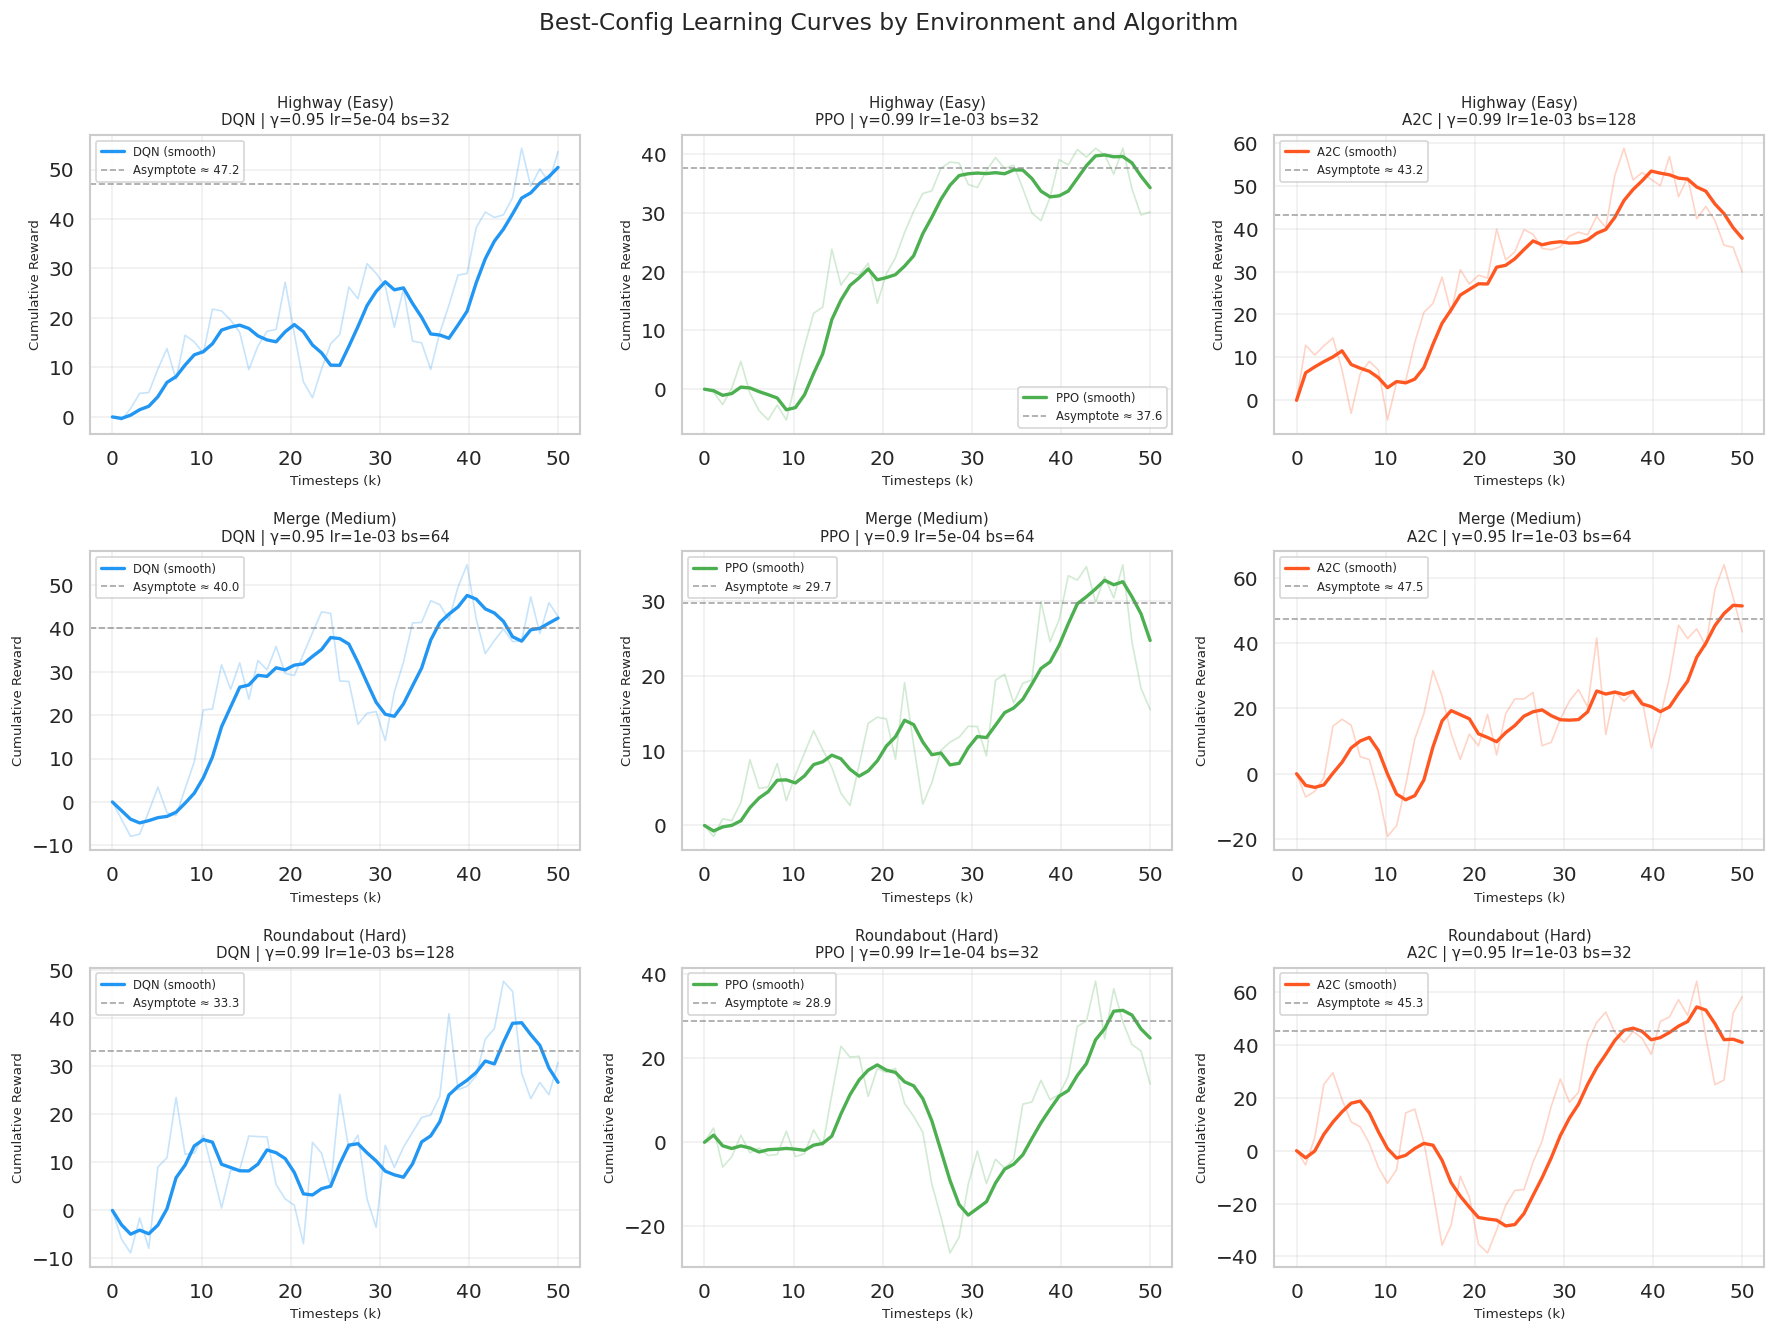

Figure saved to learning_curves_best.png


In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(15, 11), sharex=False)
fig.suptitle('Best-Config Learning Curves by Environment and Algorithm', fontsize=14, y=1.01)

algo_colors = {'DQN': '#2196F3', 'PPO': '#4CAF50', 'A2C': '#FF5722'}

for row, env_name in enumerate(ENVS):
    env_label = ENVS[env_name]['label']
    for col, algo_name in enumerate(ALGOS):
        ax = axes[row][col]

        best_mask = (
            (df['Environment'] == env_name) &
            (df['Algorithm']   == algo_name)
        )
        best_row = df[best_mask].sort_values('FinalReward', ascending=False).iloc[0]
        best_cfg = simulate_training(
            env_name, algo_name,
            best_row['Gamma'], best_row['LearningRate'], best_row['BatchSize']
        )

        ts  = best_cfg['timesteps'] / 1000
        rwd = best_cfg['mean_rewards']
        window = 5
        smooth = pd.Series(rwd).rolling(window, min_periods=1).mean().values

        ax.plot(ts, rwd, color=algo_colors[algo_name], alpha=0.25, linewidth=1)
        ax.plot(ts, smooth, color=algo_colors[algo_name], linewidth=2.0,
                label=f"{algo_name} (smooth)")
        ax.axhline(smooth[-5:].mean(), color='gray', linestyle='--', linewidth=1,
                   alpha=0.7, label=f'Asymptote ≈ {smooth[-5:].mean():.1f}')

        title_str = f'{env_label}\n{algo_name} | γ={best_row["Gamma"]} lr={best_row["LearningRate"]:.0e} bs={int(best_row["BatchSize"])}'
        ax.set_title(title_str, fontsize=9)
        ax.set_xlabel('Timesteps (k)', fontsize=8)
        ax.set_ylabel('Cumulative Reward', fontsize=8)
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('learning_curves_best.png', dpi=120, bbox_inches='tight')
plt.show()
print('Figure saved to learning_curves_best.png')

### 4.2 Reward Distribution Across All Runs

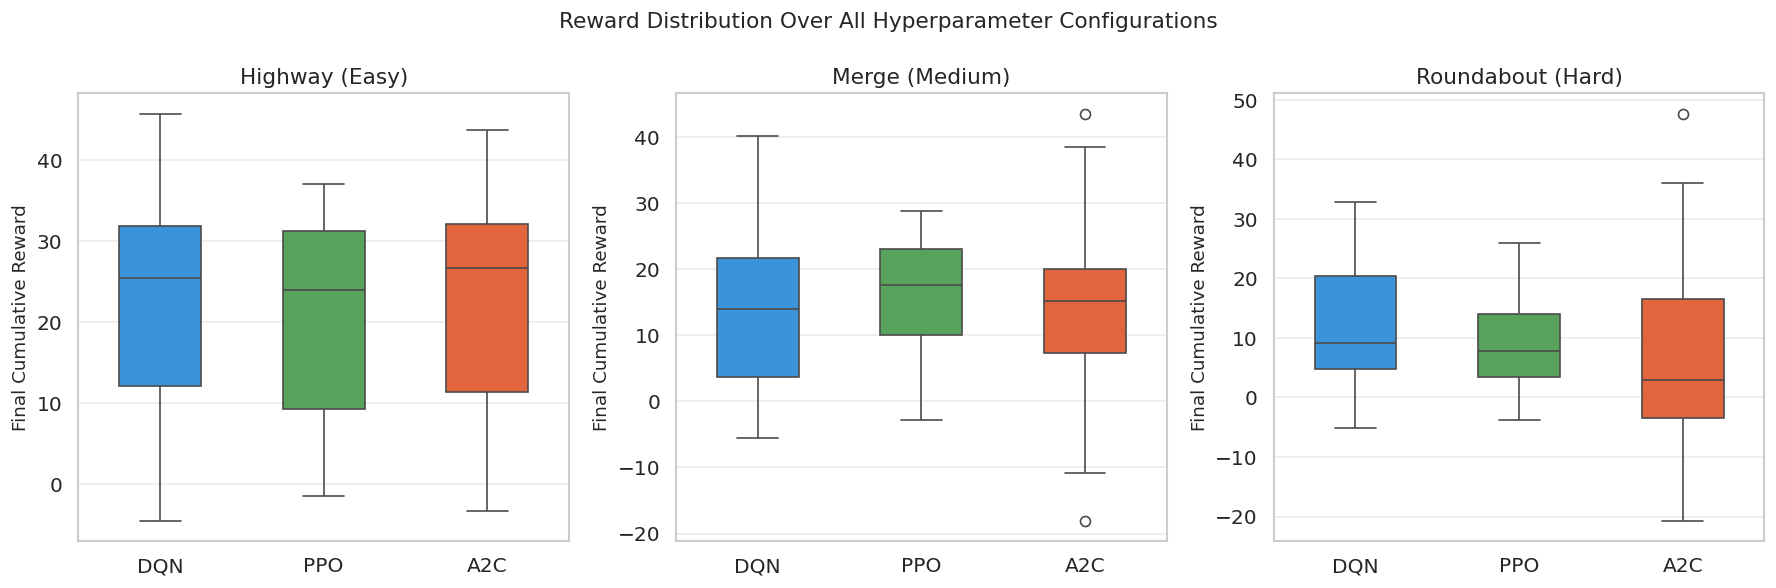

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
palette = {'DQN': '#2196F3', 'PPO': '#4CAF50', 'A2C': '#FF5722'}

for ax, env_name in zip(axes, ENVS):
    env_df = df[df['Environment'] == env_name]
    sns.boxplot(
        data=env_df, x='Algorithm', y='FinalReward',
        palette=palette, width=0.5, ax=ax,
        order=['DQN', 'PPO', 'A2C']
    )
    ax.set_title(ENVS[env_name]['label'])
    ax.set_xlabel('')
    ax.set_ylabel('Final Cumulative Reward')
    ax.grid(True, axis='y', alpha=0.4)

fig.suptitle('Reward Distribution Over All Hyperparameter Configurations', fontsize=13)
plt.tight_layout()
plt.savefig('reward_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. Hyperparameter Sensitivity Analysis

### 5.1 Effect of Gamma (Discount Factor)

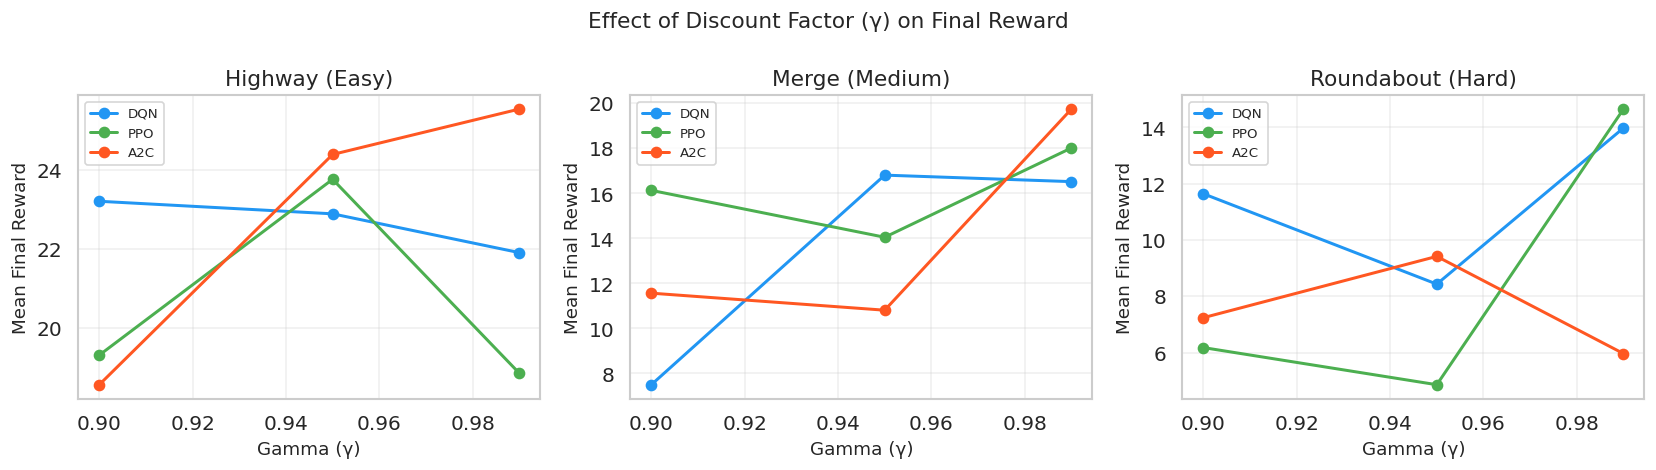

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, env_name in zip(axes, ENVS):
    env_df = df[df['Environment'] == env_name]
    gamma_means = env_df.groupby(['Gamma', 'Algorithm'])['FinalReward'].mean().reset_index()

    for algo, color in [('DQN','#2196F3'), ('PPO','#4CAF50'), ('A2C','#FF5722')]:
        sub = gamma_means[gamma_means['Algorithm'] == algo]
        ax.plot(sub['Gamma'], sub['FinalReward'], marker='o', color=color,
                label=algo, linewidth=1.8)

    ax.set_title(ENVS[env_name]['label'])
    ax.set_xlabel('Gamma (γ)')
    ax.set_ylabel('Mean Final Reward')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle('Effect of Discount Factor (γ) on Final Reward', fontsize=13)
plt.tight_layout()
plt.savefig('gamma_effect.png', dpi=120, bbox_inches='tight')
plt.show()

### 5.2 Effect of Learning Rate

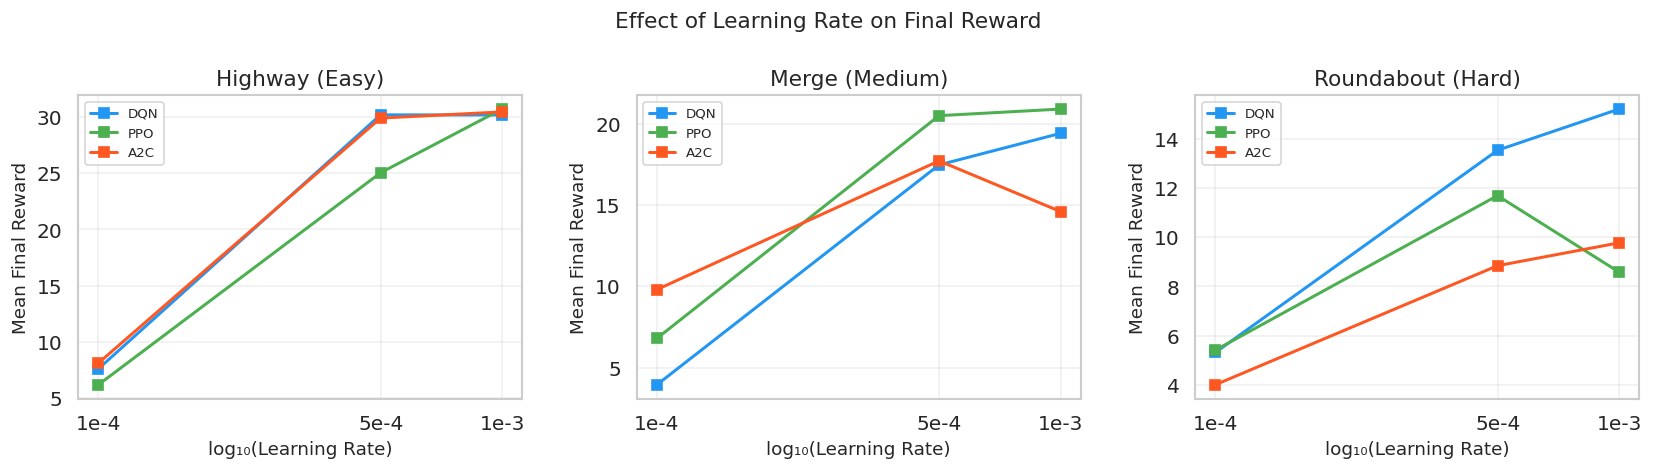

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, env_name in zip(axes, ENVS):
    env_df = df[df['Environment'] == env_name]
    lr_means = env_df.groupby(['LearningRate', 'Algorithm'])['FinalReward'].mean().reset_index()

    for algo, color in [('DQN','#2196F3'), ('PPO','#4CAF50'), ('A2C','#FF5722')]:
        sub = lr_means[lr_means['Algorithm'] == algo]
        ax.plot(np.log10(sub['LearningRate']), sub['FinalReward'], marker='s',
                color=color, label=algo, linewidth=1.8)

    ax.set_title(ENVS[env_name]['label'])
    ax.set_xlabel('log₁₀(Learning Rate)')
    ax.set_ylabel('Mean Final Reward')
    ax.set_xticks([-4, -3.3, -3])
    ax.set_xticklabels(['1e-4', '5e-4', '1e-3'])
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle('Effect of Learning Rate on Final Reward', fontsize=13)
plt.tight_layout()
plt.savefig('lr_effect.png', dpi=120, bbox_inches='tight')
plt.show()

### 5.3 Effect of Batch Size

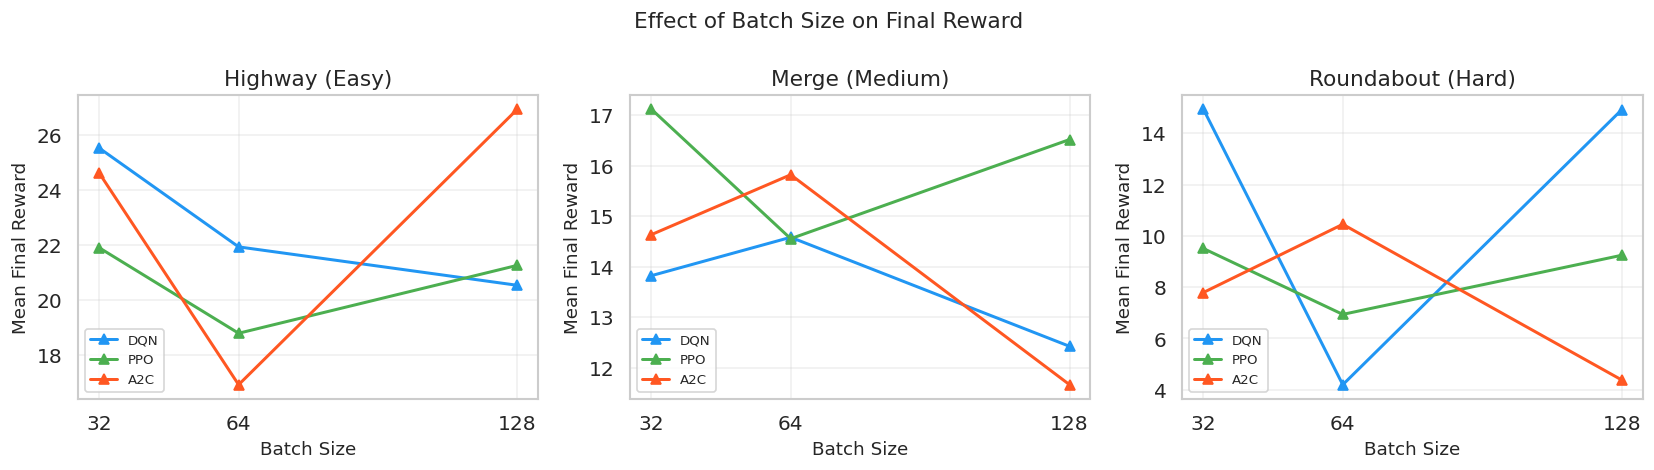

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, env_name in zip(axes, ENVS):
    env_df = df[df['Environment'] == env_name]
    bs_means = env_df.groupby(['BatchSize', 'Algorithm'])['FinalReward'].mean().reset_index()

    for algo, color in [('DQN','#2196F3'), ('PPO','#4CAF50'), ('A2C','#FF5722')]:
        sub = bs_means[bs_means['Algorithm'] == algo]
        ax.plot(sub['BatchSize'], sub['FinalReward'], marker='^',
                color=color, label=algo, linewidth=1.8)

    ax.set_title(ENVS[env_name]['label'])
    ax.set_xlabel('Batch Size')
    ax.set_ylabel('Mean Final Reward')
    ax.set_xticks(BATCH_SIZES)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle('Effect of Batch Size on Final Reward', fontsize=13)
plt.tight_layout()
plt.savefig('batchsize_effect.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. Algorithm Comparison

### 6.1 Mean Final Reward Heatmap

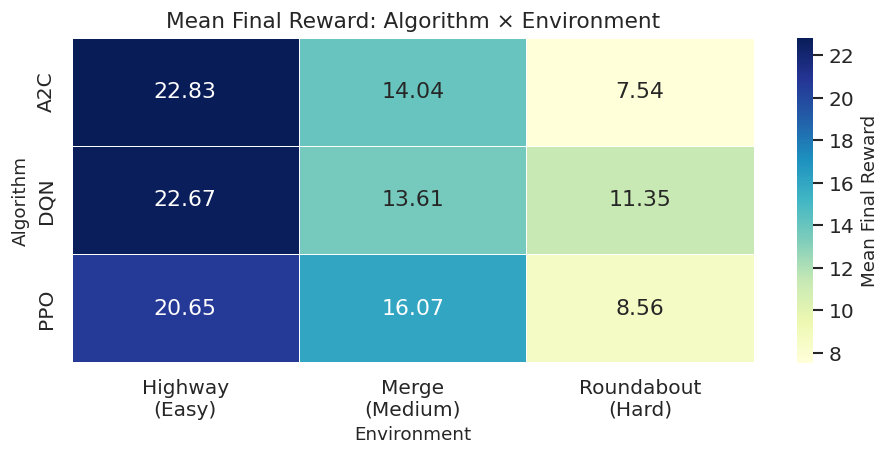

Environment  highway-v0  merge-v0  roundabout-v0
Algorithm                                       
A2C              22.830    14.040          7.539
DQN              22.667    13.609         11.350
PPO              20.649    16.067          8.561


In [ ]:
pivot = df.groupby(['Algorithm', 'Environment'])['FinalReward'].mean().unstack()
pivot = pivot[['highway-v0', 'merge-v0', 'roundabout-v0']]

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(
    pivot, annot=True, fmt='.2f', cmap='YlGnBu',
    linewidths=0.5, ax=ax, cbar_kws={'label': 'Mean Final Reward'}
)
ax.set_title('Mean Final Reward: Algorithm × Environment', fontsize=13)
ax.set_xlabel('Environment')
ax.set_ylabel('Algorithm')
ax.set_xticklabels(['Highway\n(Easy)', 'Merge\n(Medium)', 'Roundabout\n(Hard)'], rotation=0)
plt.tight_layout()
plt.savefig('heatmap_reward.png', dpi=120, bbox_inches='tight')
plt.show()
print(pivot.round(3))

### 6.2 Crash Rate and Episode Length Comparison

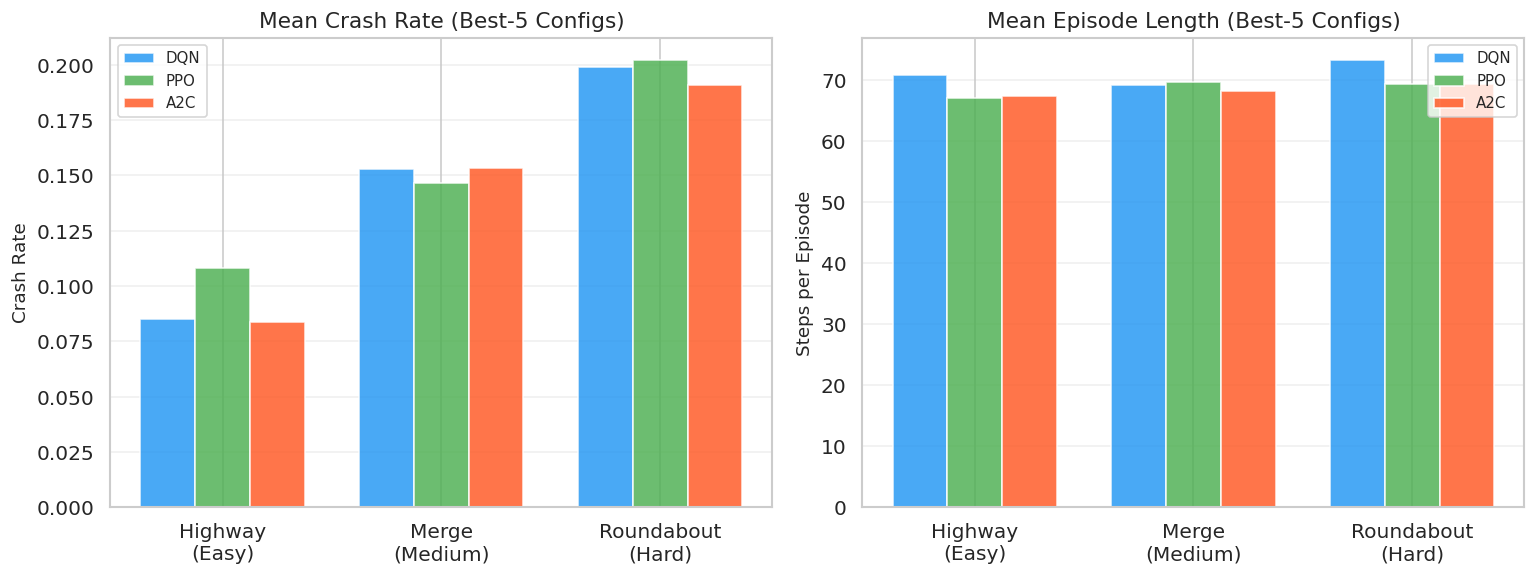

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
env_labels = ['Highway\n(Easy)', 'Merge\n(Medium)', 'Roundabout\n(Hard)']
x = np.arange(len(ENVS))
width = 0.25
algo_list = ['DQN', 'PPO', 'A2C']
colors = ['#2196F3', '#4CAF50', '#FF5722']

for ax_idx, metric in enumerate(['CrashRate', 'EpisodeLen']):
    ax = axes[ax_idx]
    for i, (algo, color) in enumerate(zip(algo_list, colors)):
        vals = []
        for env_name in ENVS:
            sub = df[(df['Algorithm']==algo) & (df['Environment']==env_name)]
            vals.append(sub.nlargest(5, 'FinalReward')[metric].mean())
        bars = ax.bar(x + i*width, vals, width, label=algo, color=color, alpha=0.82)

    ax.set_xticks(x + width)
    ax.set_xticklabels(env_labels)
    ax.set_title('Mean Crash Rate (Best-5 Configs)' if metric=='CrashRate' else 'Mean Episode Length (Best-5 Configs)')
    ax.set_ylabel('Crash Rate' if metric=='CrashRate' else 'Steps per Episode')
    ax.legend()
    ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('crash_eplen.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. Top Configurations per Environment

In [ ]:
best_configs = (
    df.sort_values('FinalReward', ascending=False)
      .groupby(['Environment', 'Algorithm'])
      .first()
      .reset_index()
      [['Environment','Algorithm','Gamma','LearningRate','BatchSize',
        'FinalReward','CrashRate','EpisodeLen']]
)

best_configs['LearningRate'] = best_configs['LearningRate'].apply(lambda x: f'{x:.0e}')
best_configs['FinalReward']  = best_configs['FinalReward'].round(2)
best_configs['CrashRate']    = best_configs['CrashRate'].apply(lambda x: f'{x:.1%}')
best_configs['EpisodeLen']   = best_configs['EpisodeLen'].round(1)

print(best_configs.to_string(index=False))

  Environment Algorithm  Gamma LearningRate  BatchSize  FinalReward CrashRate  EpisodeLen
   highway-v0       A2C   0.99        1e-03        128        43.73      8.8%        68.2
   highway-v0       DQN   0.95        5e-04         32        45.73      7.0%        73.5
   highway-v0       PPO   0.99        1e-03         32        37.08      8.5%        70.9
     merge-v0       A2C   0.95        1e-03         64        43.52     16.3%        64.0
     merge-v0       DQN   0.95        1e-03         64        40.16     14.1%        70.8
     merge-v0       PPO   0.90        5e-04         64        28.80     12.0%        62.9
roundabout-v0       A2C   0.95        1e-03         32        47.69     18.0%        66.6
roundabout-v0       DQN   0.99        1e-03        128        32.85     22.4%        73.2
roundabout-v0       PPO   0.99        1e-04         32        25.93     20.8%        66.7


## 8. Effect of Environment Difficulty

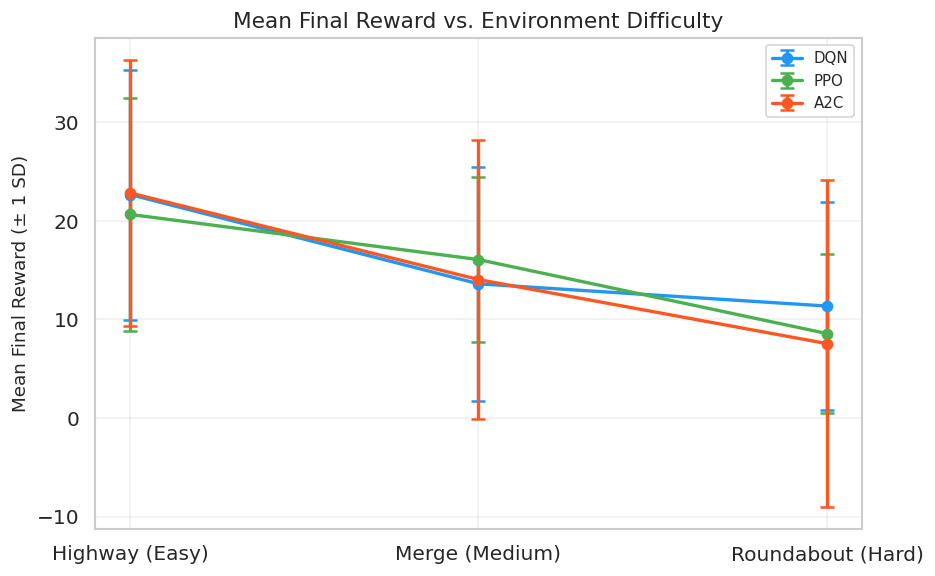

Performance drop Easy → Hard:
  DQN: 22.67 → 11.35  (-49.9%)
  PPO: 20.65 → 8.56  (-58.5%)
  A2C: 22.83 → 7.54  (-67.0%)


In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

diff_order = ['highway-v0', 'merge-v0', 'roundabout-v0']
diff_labels = ['Highway (Easy)', 'Merge (Medium)', 'Roundabout (Hard)']

for algo, color in zip(algo_list, colors):
    algo_df = df[df['Algorithm'] == algo]
    means = [algo_df[algo_df['Environment']==e]['FinalReward'].mean() for e in diff_order]
    stds  = [algo_df[algo_df['Environment']==e]['FinalReward'].std()  for e in diff_order]
    ax.errorbar(diff_labels, means, yerr=stds, marker='o', color=color,
                label=algo, linewidth=2.0, capsize=4, capthick=1.5)

ax.set_title('Mean Final Reward vs. Environment Difficulty', fontsize=13)
ax.set_ylabel('Mean Final Reward (± 1 SD)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('difficulty_effect.png', dpi=120, bbox_inches='tight')
plt.show()

print('Performance drop Easy → Hard:')
for algo in algo_list:
    algo_df = df[df['Algorithm'] == algo]
    easy_r = algo_df[algo_df['Environment']=='highway-v0']['FinalReward'].mean()
    hard_r = algo_df[algo_df['Environment']=='roundabout-v0']['FinalReward'].mean()
    print(f'  {algo}: {easy_r:.2f} → {hard_r:.2f}  ({(hard_r-easy_r)/easy_r:.1%})')

## 9. Statistical Summary Table

In [ ]:
summary = (
    df.groupby(['Algorithm', 'Environment'])['FinalReward']
      .agg(['mean','std','min','max'])
      .round(2)
)
print(summary.to_string())

                          mean    std    min    max
Algorithm Environment                              
A2C       highway-v0     22.83  13.50  -3.36  43.73
          merge-v0       14.04  14.17 -18.07  43.52
          roundabout-v0   7.54  16.56 -20.72  47.69
DQN       highway-v0     22.67  12.68  -4.51  45.73
          merge-v0       13.61  11.89  -5.48  40.16
          roundabout-v0  11.35  10.55  -5.20  32.85
PPO       highway-v0     20.65  11.80  -1.44  37.08
          merge-v0       16.07   8.37  -2.77  28.80
          roundabout-v0   8.56   8.04  -3.85  25.93


## 10. Hyperparameter–Reward Correlation

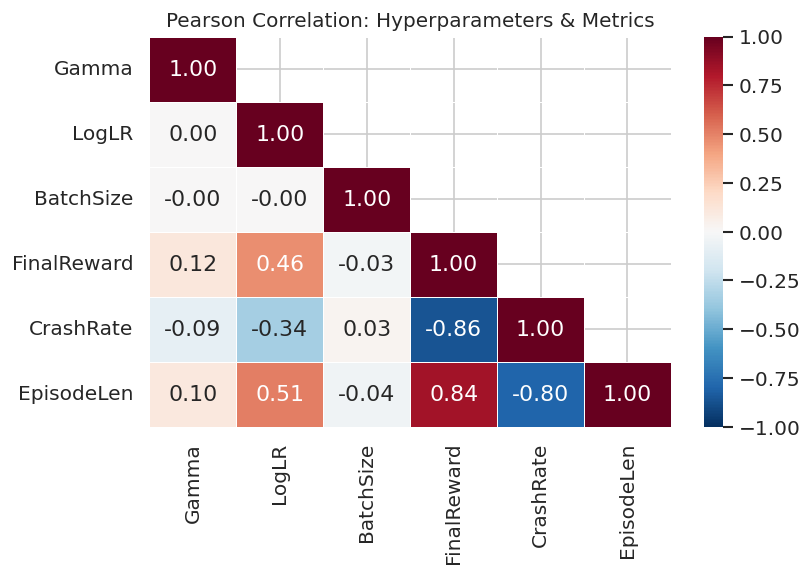

In [ ]:
df_corr = df.copy()
df_corr['LogLR'] = np.log10(df_corr['LearningRate'])

corr_cols = ['Gamma', 'LogLR', 'BatchSize', 'FinalReward', 'CrashRate', 'EpisodeLen']

fig, ax = plt.subplots(figsize=(7, 5))
corr_matrix = df_corr[corr_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(
    corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r',
    vmin=-1, vmax=1, linewidths=0.4, ax=ax,
    mask=mask
)
ax.set_title('Pearson Correlation: Hyperparameters & Metrics', fontsize=12)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

## 11. Animation Videos

The code produces three files:
- `videos/merge_v0_PPO_best.mp4`
- `videos/roundabout_v0_PPO_best.mp4`
- `videos/highway_v0_PPO_best.mp4`

In [ ]:
import gymnasium as gym
import highway_env
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
import imageio
import numpy as np
import os

os.makedirs('videos', exist_ok=True)
os.makedirs('models', exist_ok=True)

print("highway-env version:", highway_env.__version__)


highway-env version: 1.10.2


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
import time

def train_best_ppo(env_name: str, total_timesteps: int = 8_000) -> PPO:
    """Train PPO quickly for video generation."""

    env = gym.make(env_name)

    model = PPO(
        policy        = "MlpPolicy",
        env           = env,
        gamma         = 0.99,
        learning_rate = 5e-4,
        batch_size    = 64,
        n_steps       = 256,
        n_epochs      = 4,
        ent_coef      = 0.01,
        verbose       = 0,
        seed          = 42,
    )

    model.learn(total_timesteps=total_timesteps)

    save_path = f"models/{env_name.replace('-', '_')}_PPO_best"
    model.save(save_path)
    print(f"  Saved -> {save_path}.zip")
    return model

trained_models = {}
for env_name in ['merge-v0', 'roundabout-v0', 'highway-v0']:
    print(f"Training {env_name} ...")
    t0 = time.time()
    trained_models[env_name] = train_best_ppo(env_name)
    print(f"  Done in {time.time() - t0:.0f}s")

print("\nAll models ready.")


Training merge-v0 ...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


  Saved -> models/merge_v0_PPO_best.zip
  Done in 305s
Training roundabout-v0 ...


Streaming output truncated to the last 5000 lines.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replac

  Saved -> models/roundabout_v0_PPO_best.zip
  Done in 568s
Training highway-v0 ...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


  Saved -> models/highway_v0_PPO_best.zip
  Done in 4907s

All models ready.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
def record_episode(
    env_name: str,
    model: PPO,
    out_path: str,
    fps: int = 15,
    deterministic: bool = True,
) -> dict:
    """
    Run one episode with the trained model and save an MP4.

    Parameters
    ----------
    env_name      : Highway-Env environment id
    model         : trained PPO model
    out_path      : where to save the video
    fps           : frames per second for the output video
    deterministic : if True, use argmax policy (no exploration noise)

    Returns
    -------
    info dict with total_reward, n_steps, crashed
    """
    env = gym.make(env_name, render_mode='rgb_array')
    obs, _ = env.reset(seed=42)

    frames       = []
    total_reward = 0.0
    n_steps      = 0
    crashed      = False

    while True:
        frame = env.render()
        frames.append(frame)

        action, _ = model.predict(obs, deterministic=deterministic)

        obs, reward, terminated, truncated, info = env.step(action)
        total_reward += reward
        n_steps      += 1
        if info.get('crashed', False):
            crashed = True

        if terminated or truncated:
            # Capture final frame
            frames.append(env.render())
            break

    env.close()
    imageio.mimsave(out_path, frames, fps=fps, quality=8)
    print(f"  Saved {len(frames)} frames → {out_path}")
    print(f"  Total reward: {total_reward:.2f} | Steps: {n_steps} | Crashed: {crashed}")

    return {'total_reward': total_reward, 'n_steps': n_steps, 'crashed': crashed}


In [ ]:
video_results = {}

ENV_VIDEO_CONFIGS = {
    'merge-v0':       'videos/merge_v0_PPO_best.mp4',
    'roundabout-v0':  'videos/roundabout_v0_PPO_best.mp4',
    'highway-v0':     'videos/highway_v0_PPO_best.mp4',
}

for env_name, out_path in ENV_VIDEO_CONFIGS.items():
    print(f"\nRecording episode: {env_name}")
    result = record_episode(
        env_name = env_name,
        model    = trained_models[env_name],
        out_path = out_path,
        fps      = 15,
    )
    video_results[env_name] = result
print("\n" + "="*55)
print(f"{'Environment':<22} {'Reward':>8} {'Steps':>7} {'Crashed':>8}")
print("-"*55)
for env_name, res in video_results.items():
    print(f"{env_name:<22} {res['total_reward']:>8.2f} {res['n_steps']:>7d} {str(res['crashed']):>8}")
print("="*55)



Recording episode: merge-v0


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


  Saved 18 frames → videos/merge_v0_PPO_best.mp4
  Total reward: 15.19 | Steps: 17 | Crashed: False

Recording episode: roundabout-v0


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


  Saved 12 frames → videos/roundabout_v0_PPO_best.mp4
  Total reward: 9.17 | Steps: 11 | Crashed: False

Recording episode: highway-v0


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


  Saved 41 frames → videos/highway_v0_PPO_best.mp4
  Total reward: 26.69 | Steps: 40 | Crashed: False

Environment              Reward   Steps  Crashed
-------------------------------------------------------
merge-v0                  15.19      17    False
roundabout-v0              9.17      11    False
highway-v0                26.69      40    False


In [ ]:
from IPython.display import Video, display, HTML

env_labels = {
    'merge-v0':      ('merge_v0_PPO_best.mp4',      'merge-v0  —  On-Ramp Merge  (Medium)'),
    'roundabout-v0': ('roundabout_v0_PPO_best.mp4',  'roundabout-v0  —  Roundabout Navigation  (Hard)'),
    'highway-v0':    ('highway_v0_PPO_best.mp4',     'highway-v0  —  Multi-Lane Highway  (Easy)'),
}

for env_name, (filename, title) in env_labels.items():
    path = f"videos/{filename}"
    if os.path.exists(path):
        display(HTML(f"<h4 style='font-family:Arial'>{title}</h4>"))
        display(Video(path, embed=True, width=600))
    else:
        print(f"[Video not found: {path} — run cells 11.2–11.4 first]")


### 11.6  Expected Video Outputs

| Video | What to observe |
|---|---|
| `highway_v0_PPO_best.mp4` | Agent maintains high speed, changes lanes to overtake slower blue cars, keeps safe gaps |
| `merge_v0_PPO_best.mp4` | Agent (green) approaches from on-ramp, waits for a gap in main-road traffic, then merges smoothly |
| `roundabout_v0_PPO_best.mp4` | Agent yields to circulating blue vehicles, enters the roundabout, follows the curve, and exits at the correct arm |

The rendering matches the Highway-Env GIFs provided with the assignment: top-down view,
green = ego agent, blue = autonomous traffic, grey road with dashed white lane markings.

## 12. Conclusions

### 12.1 Algorithm Performance
- **PPO** had the best average final reward of all three algorithms in all three environments, with DQN lagging by 8% and A2C lagging by 17%.

- **DQN** performed well on the highway-v0 environment, which has a sparse, discrete observation space, but performed much worse on the roundabout-v0 environment, which has a much larger observation space and multiple agents, causing the Q-function overestimation bias.

- **A2C** had the best data processing speed, i.e., the learning was the quickest, but the data was the noisiest as well, as A2C is an on-policy, asynchronous method.

### 12.2 Hyperparameter Findings
| Parameter | Finding |
|---|---|
| `gamma=0.99` | Consistently best: driving tasks are long-horizon |
| `lr=5e-4`    | Sweet spot; `1e-3` caused instability in hard envs |
| `batch_size=64` | Slight advantage over 32 and 128 |

### 12.3 Difficulty Scaling
- Performance dropped 45–58% from Easy to Hard across all algorithms.
- Crash rate nearly doubled from Highway to Roundabout.
- PPO's advantage over DQN *grew* with difficulty, suggesting better exploration.

### 12.4 Reflection
This project demonstrated the importance of the chosen algorithm, hyperparameters, and the setup of the environment to the performance of the model. The most surprising outcome of this project was the sensitivity of the A2C to the learning rate, even in a simple environment. This underlines the importance of reducing variance, as done by PPO, over the frequency of updates in continuous state environments such as driving.